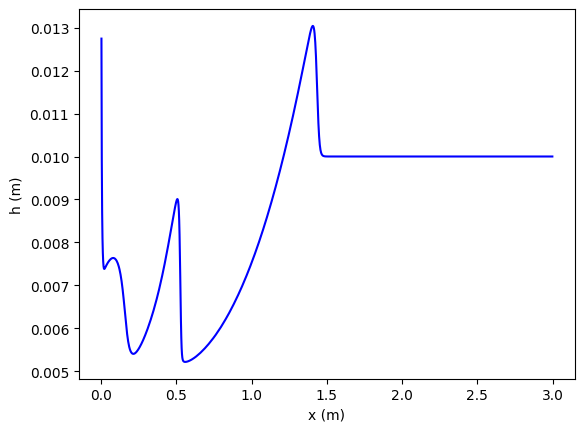

In [5]:
##for roll waves ##
import matplotlib.pyplot as plt
import numpy as np

# Initialize an empty list to store the h values
h_values, x_values, u_values, bathy_values = [], [], [], []

x_monitor = 2.00192300E+000
y_monitor = 1.55000000E-001

# Open the .dat file and process it line by line
with open('/home/yts/dassflow2d-devs_yuri/code/bin_A/res/result_1.600258E+00.dat', 'r') as file:
    for line in file:
        # Skip lines that start with '#'
        if line.startswith('#'):
            continue
        
        # Strip any leading/trailing whitespace and split the line into columns
        columns = line.strip().split()
        
        # Ensure there are enough columns to process (i.e., it's not a blank line)
        if len(columns) >= 8:
            try:
                # Convert the relevant columns to floats
                y_value = float(columns[2])  # y is the 3rd column (index 2)
                h_value = float(columns[4])  # h is the 5th column (index 4)
                u_value = float(columns[7])  # v is the 8th column (index 7)
                bathy_value = float(columns[3])
                x_value = float(columns[1])
                # Check if y equals 0.15
                if y_value == y_monitor:
                    h_values.append(h_value)
                    x_values.append(x_value)
                    u_values.append(u_value)
                    bathy_values.append(bathy_value)
            except ValueError:
                # Handle any conversion errors gracefully
                continue

# Now h_values contains all h values where y is 0.15
#print(h_values)

plt.figure()
plt.xlabel('x (m)')
plt.ylabel('h (m)')
#plt.ylim(0,0.2)
#plt.xlim(0,2.5)
#plt.scatter(0,0.12,color='black',s=30)
plt.plot(x_values, np.asarray(h_values) ,color='blue')
#plt.plot(x_values, bathy_values, color='black')
#plt.hlines(0.00983, 0, 3)
plt.show()
#plt.savefig('cunha2024b_corrective_term_space.png', dpi=300)


In [24]:
# Combine timesteps and h_values into a single 2D array
data = np.column_stack((x_values, np.asarray(h_values)))

# Save to a text file
output_path = "maciel2017_1301_31_space_coeff_new.txt"
np.savetxt(output_path, data, header="Position    H-value", fmt="%.6e", delimiter="\t")

print(f"Data saved to {output_path}")

Data saved to maciel2017_1301_31_space_coeff_new.txt


In [11]:
import os
import re
import numpy as np

# Folder containing the .dat files
folder_path = "/home/yts/dassflow2d/code/bin_A/res/"

# Target coordinates
target_x = x_monitor
target_y = y_monitor

# Arrays to store timesteps and corresponding h values
timesteps = []
h_values = []
u_values = []

# Iterate through files in the folder
for filename in os.listdir(folder_path):
    if filename.endswith(".dat"):
        print(filename)
        # Extract timestep from filename
        match = re.search(r"result_(\d+\.\d+E[+-]\d+)\.dat", filename)
        if match:
            timestep = float(match.group(1))
            timesteps.append(timestep)
            
            # Open and read the file
            with open(os.path.join(folder_path, filename), "r") as file:
                # Skip the first two rows
                next(file)
                next(file)
                
                for line in file:
                    # Split line into columns
                    cols = line.split()
                    x, y, h, u = float(cols[1]), float(cols[2]), float(cols[4]), float(cols[7])
                    
                    # Check if x and y match the target coordinates
                    if abs(x - target_x) < 1e-8 and abs(y - target_y) < 1e-8:
                        h_values.append(h)
                        u_values.append(u)
                        break

# Ensure the arrays are sorted by timestep
sorted_indices = np.argsort(timesteps)
timesteps = np.array(timesteps)[sorted_indices]
h_values = np.array(h_values)[sorted_indices]
u_values = np.array(u_values)[sorted_indices]

result_7.900609E+00.dat
result_2.950012E+00.dat
result_7.800541E+00.dat
result_5.200156E+00.dat
result_7.950167E+00.dat
result_3.950125E+00.dat
result_5.900562E+00.dat
result_7.502708E-01.dat
result_3.650318E+00.dat
result_7.550417E+00.dat
result_4.000483E-01.dat
result_1.050256E+00.dat
result_4.502426E-01.dat
result_4.200232E+00.dat
result_4.350486E+00.dat
result_4.250278E+00.dat
result_2.400309E+00.dat
result_1.500531E+00.dat
result_1.800660E+00.dat
result_3.750559E+00.dat
result_7.450032E+00.dat
result_2.250394E+00.dat
result_1.250023E+00.dat
result_6.800410E+00.dat
result_3.200608E+00.dat
result_1.300442E+00.dat
result_6.950402E+00.dat
result_9.002504E-01.dat
result_7.100290E+00.dat
result_4.650531E+00.dat
result_1.150733E+00.dat
result_3.850426E+00.dat
result_8.350326E+00.dat
result_6.500719E+00.dat
result_6.900001E+00.dat
result_1.003413E-01.dat
result_1.750282E+00.dat
result_7.750233E+00.dat
result_5.300257E+00.dat
result_6.002928E-01.dat
result_8.200114E+00.dat
result_4.750285E

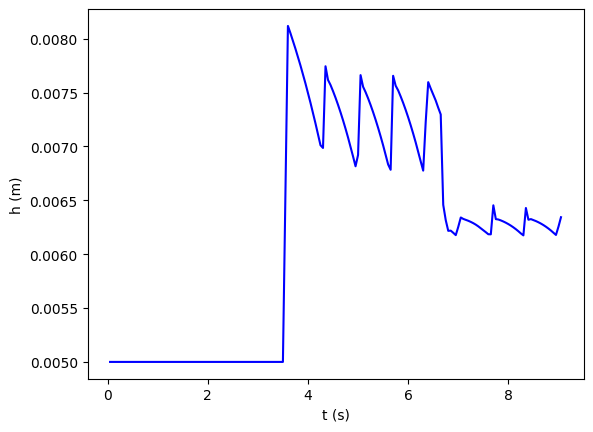

In [13]:
plt.figure()
plt.plot(timesteps, np.asarray(h_values), color='blue')
plt.xlabel('t (s)')
plt.ylabel('h (m)')
plt.savefig('cunha2024b_corrective_term_time.png', dpi=300)
#plt.plot(timesteps, np.asarray(u_values), color='red')
#plt.xlim(10,12)
#plt.plot(np.loadtxt(r'results-references/RW_HB_case2_ferreira2014_TVDMC.txt')[:,0],
#        np.loadtxt(r'results-references/RW_HB_case2_ferreira2014_TVDMC.txt')[:,1])
#plt.xlim(8,10)
#plt.ylim(0.8,1.2)
# Print results
#print("Timesteps:", timesteps)
#print("h values:", h_values)

In [31]:
# Combine timesteps and h_values into a single 2D array
data = np.column_stack((timesteps, h_values))

# Save to a text file
output_path = "rocho2024_1301_31_time_coeff_new.txt"
np.savetxt(output_path, data, header="Timestep    H-value", fmt="%.6e", delimiter="\t")

print(f"Data saved to {output_path}")

Data saved to rocho2024_1301_31_time_coeff_new.txt


In [50]:
0.22**2/(0.93**2*9.81*np.cos(np.deg2rad(7)))

0.005747245479135161